In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv')


ModuleNotFoundError: No module named 'pandas'

In [ ]:

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("Missing values in the dataset:")
print(df.isnull().sum())

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop('Cabin', axis=1)

Missing values in the dataset:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64



1. Survival Counts:
Survived: 342
Not Survived: 549


/tmp/ipython-input-7-1544936392.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette=['#FF6384', '#36A2EB'])


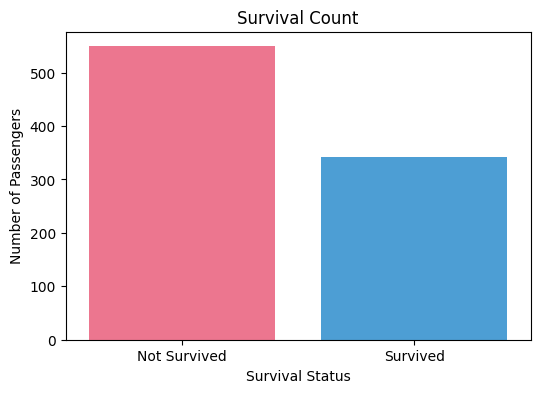

In [ ]:
survival_counts = df['Survived'].value_counts()
print(f"\n1. Survival Counts:\nSurvived: {survival_counts[1]}\nNot Survived: {survival_counts[0]}")
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, palette=['#FF6384', '#36A2EB'])
plt.title('Survival Count')
plt.xlabel('Survival Status')
plt.ylabel('Number of Passengers')
plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.show()


2. Survival Percentage:
Female: 74.20%
Male: 18.89%


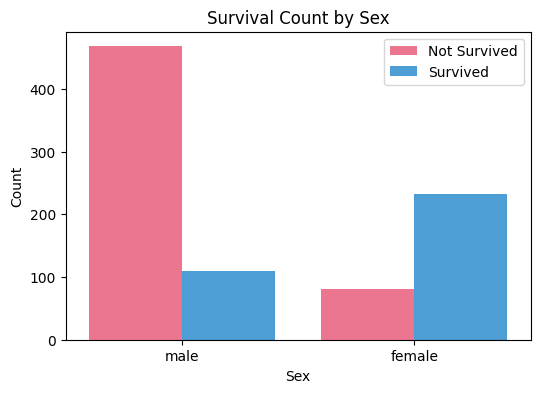

In [ ]:
female_survived = df[df['Sex'] == 'female']['Survived'].mean() * 100
male_survived = df[df['Sex'] == 'male']['Survived'].mean() * 100
print(f"\n2. Survival Percentage:\nFemale: {female_survived:.2f}%\nMale: {male_survived:.2f}%")
plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', hue='Survived', data=df, palette=['#FF6384', '#36A2EB'])
plt.title('Survival Count by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(['Not Survived', 'Survived'])
plt.show()


3. Survival Rate by Passenger Class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64
Highest survival rate: Class 1 (62.96%)


/tmp/ipython-input-9-1754522084.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, palette=['#36A2EB', '#FFCE56', '#FF6384'])


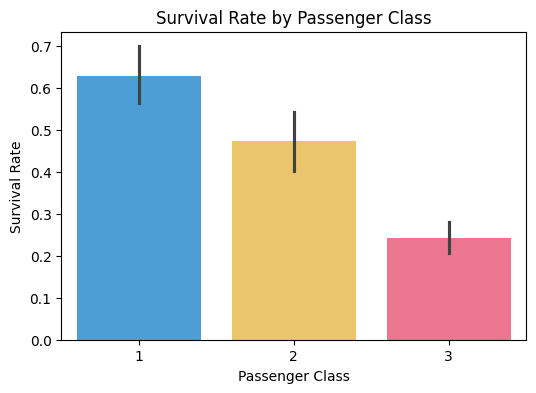

In [ ]:
pclass_survival = df.groupby('Pclass')['Survived'].mean() * 100
print("\n3. Survival Rate by Passenger Class:")
print(pclass_survival)
print(f"Highest survival rate: Class {pclass_survival.idxmax()} ({pclass_survival.max():.2f}%)")
plt.figure(figsize=(6, 4))
sns.barplot(x='Pclass', y='Survived', data=df, palette=['#36A2EB', '#FFCE56', '#FF6384'])
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

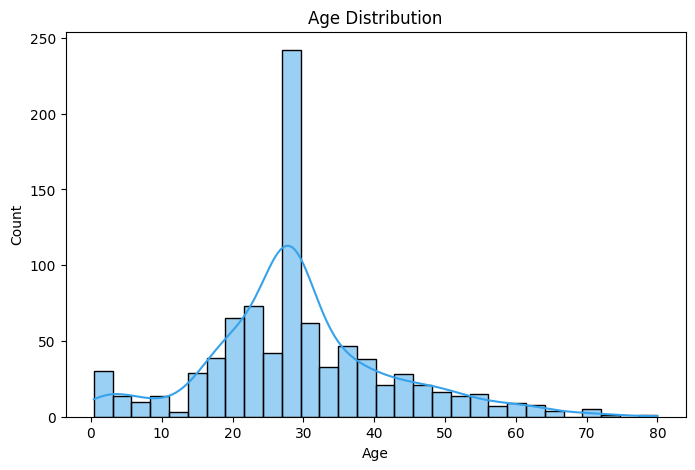


4. Average Age:
Survivors: 28.29
Non-Survivors: 30.03


In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True, color='#36A2EB')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()
avg_age_survived = df[df['Survived'] == 1]['Age'].mean()
avg_age_not_survived = df[df['Survived'] == 0]['Age'].mean()
print(f"\n4. Average Age:\nSurvivors: {avg_age_survived:.2f}\nNon-Survivors: {avg_age_not_survived:.2f}")


5. Survival Rate by Family Presence:
With Family: 50.56%
Without Family: 30.35%


/tmp/ipython-input-11-2000050426.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='HasFamily', y='Survived', data=df, palette=['#FF6384', '#36A2EB'])


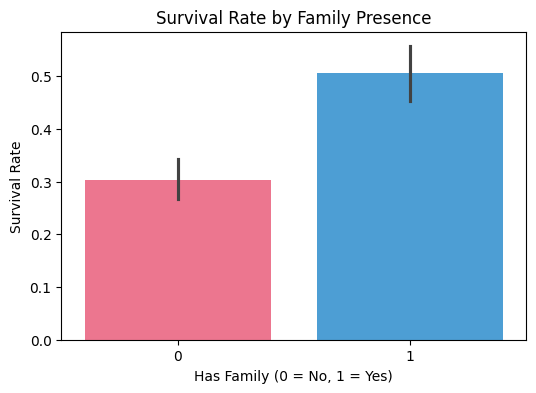

In [ ]:
df['HasFamily'] = (df['SibSp'] + df['Parch'] > 0).astype(int)
family_survival = df.groupby('HasFamily')['Survived'].mean() * 100
print("\n5. Survival Rate by Family Presence:")
print(f"With Family: {family_survival[1]:.2f}%")
print(f"Without Family: {family_survival[0]:.2f}%")
plt.figure(figsize=(6, 4))
sns.barplot(x='HasFamily', y='Survived', data=df, palette=['#FF6384', '#36A2EB'])
plt.title('Survival Rate by Family Presence')
plt.xlabel('Has Family (0 = No, 1 = Yes)')
plt.ylabel('Survival Rate')
plt.show()

In [ ]:
avg_fare = df['Fare'].mean()
high_fare_survival = df[df['Fare'] > avg_fare]['Survived'].mean() * 100
print(f"\n6. Survival Rate for Fare > Average ({avg_fare:.2f}): {high_fare_survival:.2f}%")


6. Survival Rate for Fare > Average (32.20): 59.72%


/tmp/ipython-input-13-3424281403.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_survival = df.groupby('AgeGroup')['Survived'].mean() * 100
/tmp/ipython-input-13-3424281403.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AgeGroup', y='Survived', data=df, palette=['#36A2EB', '#FFCE56', '#FF6384'])



7. Survival Rate by Age Group:
AgeGroup
Child     55.000000
Adult     36.671001
Senior    22.727273
Name: Survived, dtype: float64
Highest survival rate: Child (55.00%)


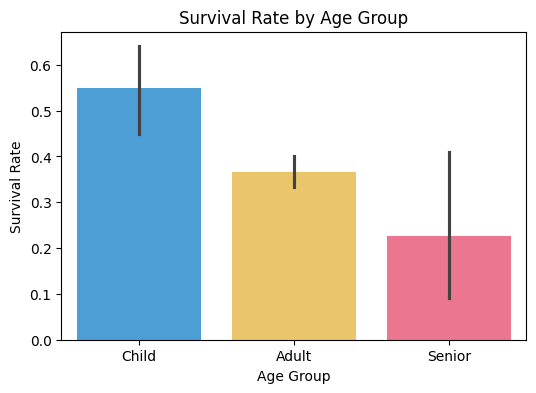

In [ ]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 16, 60, df['Age'].max()], labels=['Child', 'Adult', 'Senior'])
age_group_survival = df.groupby('AgeGroup')['Survived'].mean() * 100
print("\n7. Survival Rate by Age Group:")
print(age_group_survival)
print(f"Highest survival rate: {age_group_survival.idxmax()} ({age_group_survival.max():.2f}%)")
plt.figure(figsize=(6, 4))
sns.barplot(x='AgeGroup', y='Survived', data=df, palette=['#36A2EB', '#FFCE56', '#FF6384'])
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.show()

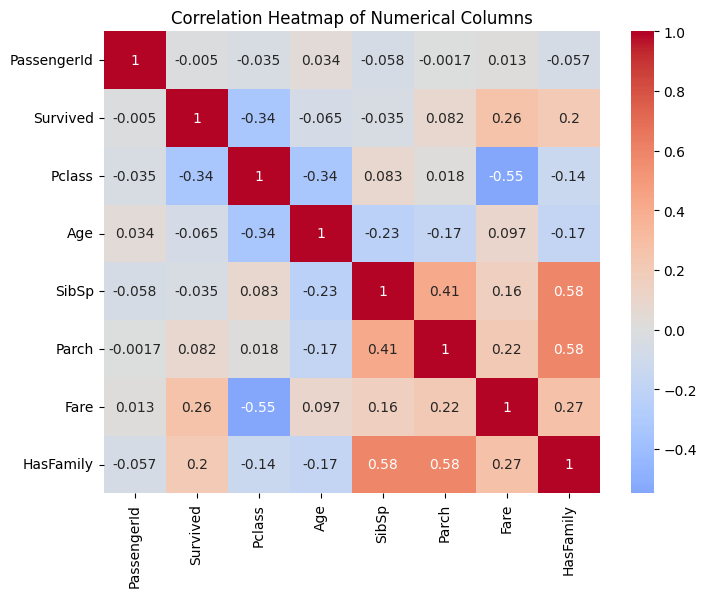

In [ ]:
plt.figure(figsize=(8, 6))
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()


10. Survival Counts by Embarked Location:
Survived    0    1
Embarked          
C          75   93
Q          47   30
S         427  219

Survival Rate by Embarked Location:
Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64
Highest survival rate: C (55.36%)


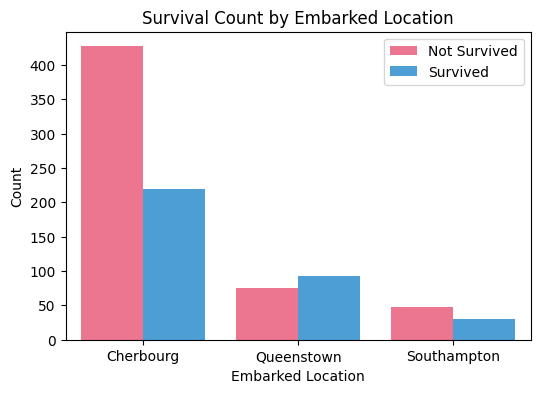

In [ ]:
embarked_survival = df.groupby('Embarked')['Survived'].value_counts().unstack().fillna(0)
embarked_survival_rate = df.groupby('Embarked')['Survived'].mean() * 100

# Print survival counts
print("\n10. Survival Counts by Embarked Location:")
print(embarked_survival)

# Print survival rates and highest
print("\nSurvival Rate by Embarked Location:")
print(embarked_survival_rate)
print(f"Highest survival rate: {embarked_survival_rate.idxmax()} ({embarked_survival_rate.max():.2f}%)")

# Plot survival counts
plt.figure(figsize=(6, 4))
sns.countplot(x='Embarked', hue='Survived', data=df, palette=['#FF6384', '#36A2EB'])
plt.title('Survival Count by Embarked Location')
plt.xlabel('Embarked Location')
plt.ylabel('Count')
plt.xticks([0, 1, 2], ['Cherbourg', 'Queenstown', 'Southampton'])
plt.legend(['Not Survived', 'Survived'])
plt.show()

In [ ]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv('train.csv')
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop('Cabin', axis=1)
df['HasFamily'] = (df['SibSp'] + df['Parch'] > 0).astype(int)
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 16, 60, df['Age'].max()], labels=['Child', 'Adult', 'Senior'])

df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked', 'AgeGroup'], drop_first=True)
X = df_encoded.drop(['Survived', 'PassengerId', 'Name', 'Ticket'], axis=1)
y = df_encoded['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f" Random Forest Accuracy: {accuracy:.4f}")

 Random Forest Accuracy: 0.8212


In [ ]:
n_estimators_list = [10, 100, 500]
for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f" Accuracy with n_estimators={n}: {accuracy:.4f}")

 Accuracy with n_estimators=10: 0.8212
 Accuracy with n_estimators=100: 0.8212
 Accuracy with n_estimators=500: 0.8212


In [ ]:
predictions = rf.predict(X_test.iloc[:10])
actual = y_test.iloc[:10]
print("\n13. Predictions vs Actual for First 10 Rows:")
print(pd.DataFrame({'Actual': actual, 'Predicted': predictions}))


13. Predictions vs Actual for First 10 Rows:
     Actual  Predicted
709       1          0
439       0          0
840       0          0
720       1          1
39        1          0
290       1          1
300       1          1
333       0          0
208       1          1
136       1          1


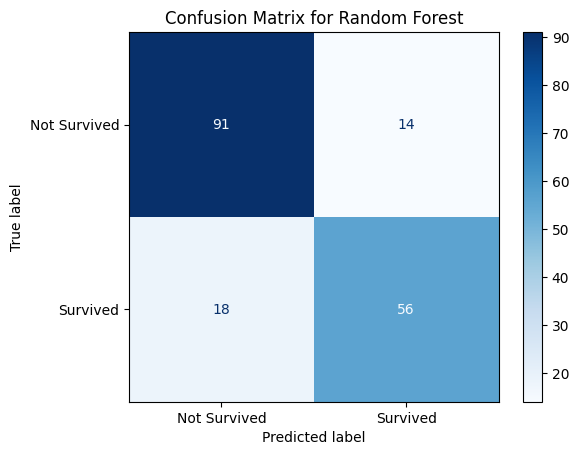

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Random Forest')
plt.show()

In [ ]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(" Top 3 Most Important Features:")
print(feature_importance.head(3))

 Top 3 Most Important Features:
Fare        0.269225
Sex_male    0.268157
Age         0.231024
dtype: float64


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print(f" Cross-Validation Scores: {scores}")
print(f"Average Accuracy: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

 Cross-Validation Scores: [0.79329609 0.80337079 0.84831461 0.76966292 0.83707865]
Average Accuracy: 0.8103 (+/- 0.0576)


In [ ]:
max_depth_list = [3, 5, 10, None]
for depth in max_depth_list:
    rf = RandomForestClassifier(max_depth=depth, random_state=42)
    rf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, rf.predict(X_train))
    test_acc = accuracy_score(y_test, rf.predict(X_test))
    print(f" Max Depth={depth}: Train Accuracy={train_acc:.4f}, Test Accuracy={test_acc:.4f}")

 Max Depth=3: Train Accuracy=0.8329, Test Accuracy=0.8212
 Max Depth=5: Train Accuracy=0.8469, Test Accuracy=0.8268
 Max Depth=10: Train Accuracy=0.9396, Test Accuracy=0.8212
 Max Depth=None: Train Accuracy=0.9789, Test Accuracy=0.8212


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_accuracy = accuracy_score(y_test, dt.predict(X_test))
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_accuracy = accuracy_score(y_test, rf.predict(X_test))
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Decision Tree Accuracy: 0.7933
Random Forest Accuracy: 0.8212
